### Plan-Execute 패턴 웹 브라우징 적용

이 워크플로우는 사용자의 복잡한 지시사항을 웹 브라우저 환경에서 실행하기 위한 것이다. Plan-Execute 패턴을 기반으로 하며, 계획 수립 단계에서 사전 검증 과정을 추가하여 효율성과 안정성을 높인 것이 특징이다.

---

#### 워크플로우 단계

-   **Plan (계획)**:
    -   사용자의 질의를 분석하여 목표를 파악하는 단계이다.
    -   지시사항 이행에 필요한 웹페이지의 특정 요소(예: 검색창) 존재 여부를 확인하기 위해 웹페이지를 분석한다.
    -   **사전 검증 성공**: 지시사항 실행이 가능하다고 판단될 경우, 구체적인 단계별 실행 계획을 수립한다.
    -   **사전 검증 실패**: 지시사항 실행이 불가능하다고 판단될 경우, 불가능한 이유를 사용자에게 알리고 워크플로우를 종료한다.

-   **Execute (실행)**:
    -   계획 단계에서 수립된 각 단계를 순서대로 실행하는 단계이다.
    -   웹페이지 요소를 조작하거나 정보를 추출하는 등의 작업을 수행한다.
    -   예상치 못한 문제가 발생할 경우, **Human-in-the-Loop**를 통해 사용자에게 도움을 요청할 수 있다.

-   **Replan (재계획)**:
    -   실행 단계에서 예외 상황이나 오류가 발생했을 때 계획을 재수립하는 단계이다.
    -   오류의 원인을 분석하고, 새로운 실행 계획을 수립하여 다시 `Execute` 단계로 돌아간다.

-   **Final Response (최종 응답)**:
    -   모든 계획이 성공적으로 실행되었거나, 실행이 불가능하다고 판단되었을 때 최종 결과를 사용자에게 전달하는 단계이다.
    -   목표 달성 여부와 그 과정에 대한 보고서를 제공하여 워크플로우를 마무리한다.

---

#### Human-in-the-Loop (HITL)

Human-in-the-Loop는 실행 과정에서 발생하는 불확실한 상황(예: 여러 개의 검색창)에 대해 사용자의 직접적인 판단을 요청하는 기능이다. 이를 통해 워크플로우의 정확성을 높이고 실패율을 줄인다.

In [23]:
import operator
from typing import Annotated, Any, List, Literal, Tuple
from typing_extensions import TypedDict
from pydantic import BaseModel, Field


# TypedDict 사용하여 정적 타입 힌트 적용 위함
# 상태 정의
class WebBrowsingState(TypedDict):
    input: Annotated[str, "User's input"]
    plan: Annotated[List[str], "Current plan"]
    past_steps: Annotated[List[Tuple], operator.add]
    response: Annotated[str, "Final response"]

# BaseModel사용하여 런타임 데이터 검증과 구조화된 출력 위함
# Plan 모델 정의
class Plan(BaseModel):
    steps: Annotated[List[str], "Different steps to follow, should be in sorted order"]

# 사용자 응답 및 계획 재수립 모델 정의
class Response(BaseModel):
    response: str = Field(description="The final response to the user.")

class Plan(BaseModel):
    steps: list[str] = Field(description="List of steps to be performed.")

In [ ]:
from langchain_core.tools import tool

# 로컬 HTML 파일을 읽는 도구
@tool
def read_local_html(file_path: str) -> str:
    """로컬 HTML 파일의 내용을 읽는 함수."""
    print(f"웹페이지 파일({file_path})을 읽었습니다.")
    with open(file_path, 'r', encoding='utf-8') as f:
        return f.read()


In [25]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
load_dotenv()

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

E0000 00:00:1758811596.290349  127766 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


In [26]:
from langchain_core.prompts import ChatPromptTemplate

# Planner 프롬프트 정의
planner_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """주어진 목표에 대해 간단한 단계별 계획을 세워주세요.
이 계획은 정확한 답을 도출하는 데 필요한 개별적인 작업들로 구성되어야 합니다.
불필요한 단계는 추가하지 마세요. 마지막 단계의 결과가 최종 답변이어야 합니다.
각 단계에 필요한 모든 정보가 포함되어 있는지 확인하고, 단계를 건너뛰지 마세요.
답변은 한글로 작성하세요.""",
        ),
        ("placeholder", "{messages}"),
    ]
)

planner = planner_prompt | llm.with_structured_output(Plan)


In [27]:
from bs4 import BeautifulSoup

# 노드 함수 정의
def plan_step(state: WebBrowsingState):
    """사용자 입력에 따라 계획을 수립하고 실행 가능성을 검증합니다."""
    # 수정된 부분
    html_content = read_local_html.invoke("dummy_page.html")
    soup = BeautifulSoup(html_content, 'html.parser')

    # 웹페이지에서 검색창이 있는지 검증
    search_input = soup.find('input', {'name': 'q'})
    
    if search_input:
        print("▶︎ 계획 단계: 검색창이 존재함을 확인했습니다. 실행 가능한 계획을 수립합니다.")
        plan = planner.invoke({"messages": [("user", state["input"])]})
        new_plan = [
            f"검색창에 '{state['input']}'을(를) 입력합니다.",
            "검색을 실행합니다.",
            "검색 결과를 분석하여 사용자에게 보고서를 작성합니다."
        ]
        return {"plan": new_plan}
    else:
        print("▶︎ 계획 단계: 페이지에 검색창이 없습니다. 계획 수립에 실패했습니다.")
        return {"response": "해당 웹페이지에 검색 기능이 없어 '"+state['input']+"' 작업을 이행할 수 없습니다."}

def execute_step(state: WebBrowsingState):
    """계획의 첫 번째 단계를 콘솔에 출력하며 실행을 시뮬레이션합니다."""
    task = state["plan"][0]
    print(f"▶︎ 실행 단계: '{task}' 작업을 수행했습니다. (시뮬레이션)")
    
    # 실행 결과를 past_steps에 추가
    return {
        "past_steps": [(task, f"'{task}' 작업이 성공적으로 실행되었습니다.")],
        "plan": state["plan"][1:],  # 완료된 작업은 계획에서 제거
    }


def replan_step(state: WebBrowsingState):
    """남은 계획을 바탕으로 다음 단계로 진행할지, 아니면 종료할지 결정합니다."""
    if not state["plan"]:
        return {"response": "계획된 모든 작업이 완료되었습니다."}
    else:
        print("▶︎ 재계획 단계: 남은 계획이 있어 다음 실행 단계로 이동합니다.")
        return {"plan": state["plan"]}


def should_end(state: WebBrowsingState):
    """에이전트의 실행 종료 여부를 결정합니다."""
    if "response" in state and state["response"]:
        return "final_report"
    else:
        return "execute"


In [28]:
from langchain_core.output_parsers import StrOutputParser

# 최종 보고서 생성
final_report_prompt = ChatPromptTemplate.from_template(
    """당신에게는 목표와 이전에 완료된 단계들이 주어졌습니다. 당신의 임무는 마크다운 형식으로 최종 보고서를 생성하는 것입니다.
최종 보고서는 전문적인 어조로 작성되어야 합니다.

당신의 목표는 다음과 같습니다:
{input}

당신이 시뮬레이션으로 완료한 단계들(작업과 결과):
{past_steps}

마크다운 형식으로 최종 보고서를 생성하세요. 답변은 한글로 작성하세요."""
)

final_report = (
    final_report_prompt
    | llm
    | StrOutputParser()
)

In [29]:
def generate_final_report(state: WebBrowsingState):
    """최종 보고서를 생성합니다."""
    past_steps = "\n\n".join(
        [
            f"작업: {past_step[0]}\n\n결과: {past_step[1]}\n\n####"
            for past_step in state["past_steps"]
        ]
    )
    response = final_report.invoke({"input": state["input"], "past_steps": past_steps})
    return {"response": response}

In [30]:
from langgraph.graph import StateGraph, START, END
from langchain_core.runnables import RunnableLambda
from langgraph.checkpoint.memory import MemorySaver

# 그래프 생성 및 컴파일
workflow = StateGraph(WebBrowsingState)

workflow.add_node("planner", RunnableLambda(plan_step))
workflow.add_node("execute", RunnableLambda(execute_step))
workflow.add_node("replan", RunnableLambda(replan_step))
workflow.add_node("final_report", RunnableLambda(generate_final_report))

# 올바른 엣지 연결
workflow.add_edge(START, "planner")
workflow.add_edge("planner", "execute")
workflow.add_edge("execute", "replan")  # ★ 이 엣지가 추가되어야 합니다.
workflow.add_edge("final_report", END)

workflow.add_conditional_edges(
    "replan",
    should_end,
    {"execute": "execute", "final_report": "final_report"},
)

# 그래프 컴파일
app = workflow.compile(checkpointer=MemorySaver())


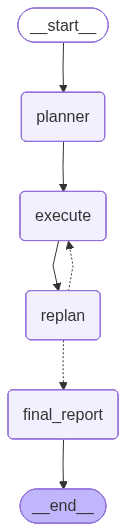

In [31]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    pass

In [32]:
import uuid

# 실행
query = "케이팝데몬헌터스에 대해 검색하고 설명해줘."
result = app.invoke(
    {"input": query},
    config={"configurable": {"thread_id": str(uuid.uuid4())}}
)

print("\n--- 최종 결과 ---")
print(result)




웹페이지 파일(dummy_page.html)을 읽었습니다.
▶︎ 계획 단계: 검색창이 존재함을 확인했습니다. 실행 가능한 계획을 수립합니다.
▶︎ 실행 단계: '검색창에 '케이팝데몬헌터스에 대해 검색하고 설명해줘.'을(를) 입력합니다.' 작업을 수행했습니다. (시뮬레이션)
▶︎ 재계획 단계: 남은 계획이 있어 다음 실행 단계로 이동합니다.
▶︎ 실행 단계: '검색을 실행합니다.' 작업을 수행했습니다. (시뮬레이션)
▶︎ 재계획 단계: 남은 계획이 있어 다음 실행 단계로 이동합니다.
▶︎ 실행 단계: '검색 결과를 분석하여 사용자에게 보고서를 작성합니다.' 작업을 수행했습니다. (시뮬레이션)

--- 최종 결과 ---
{'input': '케이팝데몬헌터스에 대해 검색하고 설명해줘.', 'plan': [], 'past_steps': [("검색창에 '케이팝데몬헌터스에 대해 검색하고 설명해줘.'을(를) 입력합니다.", "'검색창에 '케이팝데몬헌터스에 대해 검색하고 설명해줘.'을(를) 입력합니다.' 작업이 성공적으로 실행되었습니다."), ('검색을 실행합니다.', "'검색을 실행합니다.' 작업이 성공적으로 실행되었습니다."), ('검색 결과를 분석하여 사용자에게 보고서를 작성합니다.', "'검색 결과를 분석하여 사용자에게 보고서를 작성합니다.' 작업이 성공적으로 실행되었습니다.")], 'response': "# 케이팝 데몬 헌터스 최종 보고서\n\n## 1. 목표\n본 보고서의 목표는 '케이팝 데몬 헌터스'에 대한 정보를 검색하고 설명하는 것입니다.\n\n## 2. 수행 과정\n다음과 같은 단계들이 시뮬레이션으로 완료되었습니다:\n*   검색창에 '케이팝 데몬 헌터스에 대해 검색하고 설명해줘.'를 입력했습니다.\n*   검색을 실행했습니다.\n*   검색 결과를 분석하여 보고서를 작성했습니다.\n\n모든 작업은 성공적으로 실행되었습니다.\n\n## 3. '케이팝 데몬 헌터스'에 대한 설명\n'케이팝 데몬 헌터스(K-Pop Demon Hunters)'는 K-Pop 아이돌의